In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

df = pd.read_excel('DatosRegresion15D.xlsx')
print(df.shape)
df.head()

(1000, 16)


,ingresos,habitantes,potencia,piso,adosado,casa,superficie,HorInv,HorVer,edad,soltero,casado,separado,viudo,estudios,consumo
0,73.448350,1.878841,10.35,0,1,0,128.945592,7.537524,2.936068,32.810028,0,0,0,1,5,8.139525
1,15.753843,4.393693,3.45,1,0,0,56.618848,17.658045,7.055483,25.269626,1,0,0,0,1,2.657881
2,16.817903,4.308961,3.45,1,0,0,47.870539,17.334392,8.016306,24.056044,1,0,0,0,1,2.672629
3,11.004995,5.486872,3.45,1,0,0,58.040246,18.571945,8.849552,23.115285,1,0,0,0,1,2.838578
4,78.664386,1.145040,11.50,0,1,0,170.468416,6.655750,1.765829,32.992481,0,0,1,0,5,8.184366


## Regresión Lineal Múltiple
Predice `ingresos` usando todas las demás variables como features.

In [23]:
X = df.drop('ingresos', axis=1)
y = df['ingresos']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Curva de aprendizaje:** MSE en train/test para distintos tamaños de entrenamiento.

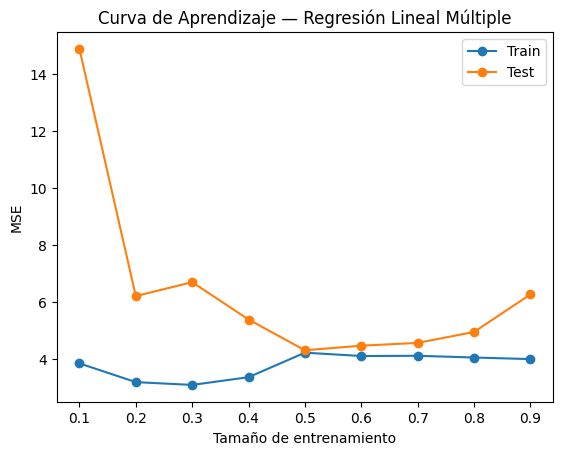

In [24]:
train_sizes = np.linspace(0.1, 0.9, 9)
train_errors, test_errors = [], []

for train_size in train_sizes:
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=1-train_size, random_state=42)
    m = LinearRegression().fit(Xtr, ytr)
    train_errors.append(mean_squared_error(ytr, m.predict(Xtr)))
    test_errors.append(mean_squared_error(yte, m.predict(Xte)))

plt.plot(train_sizes, train_errors, label='Train', marker='o')
plt.plot(train_sizes, test_errors, label='Test', marker='o')
plt.xlabel('Tamaño de entrenamiento')
plt.ylabel('MSE')
plt.title('Curva de Aprendizaje — Regresión Lineal Múltiple')
plt.legend()
plt.show()

## Regresión Polinómica
Predice `ingresos` desde `consumo` con `PolynomialFeatures`.

In [25]:
X_poly = df[['consumo']].values
y_poly = df['ingresos'].values.reshape(-1, 1)

Xp_train, Xp_test, yp_train, yp_test = train_test_split(
    X_poly, y_poly, test_size=0.2, random_state=42
)

**MSE vs grado del polinomio** (1–49): detecta el grado óptimo antes del sobreajuste.

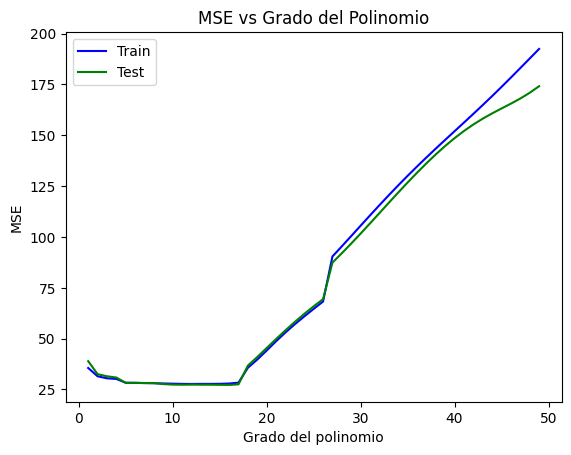

In [26]:
grados = range(1, 50)
train_errors_g, test_errors_g = [], []

for g in grados:
    poly = PolynomialFeatures(degree=g)
    Xtr_g = poly.fit_transform(Xp_train)
    Xte_g = poly.transform(Xp_test)
    m = LinearRegression().fit(Xtr_g, yp_train)
    train_errors_g.append(mean_squared_error(yp_train, m.predict(Xtr_g)))
    test_errors_g.append(mean_squared_error(yp_test, m.predict(Xte_g)))

plt.plot(grados, train_errors_g, label='Train', color='blue')
plt.plot(grados, test_errors_g, label='Test', color='green')
plt.xlabel('Grado del polinomio')
plt.ylabel('MSE')
plt.title('MSE vs Grado del Polinomio')
plt.legend()
plt.show()

**Curva de aprendizaje** con grado fijo = 7.

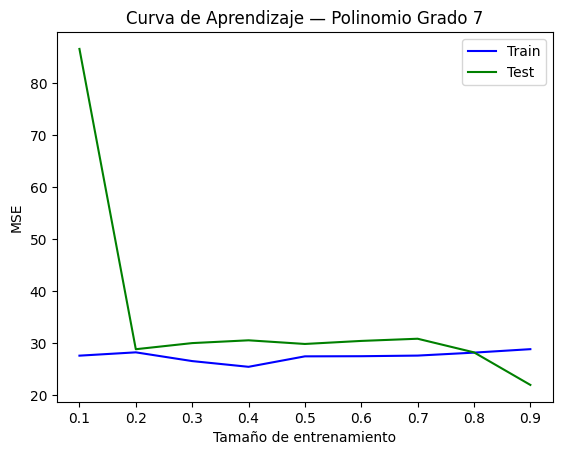

In [27]:
GRADO = 7
train_sizes = np.linspace(0.1, 0.9, 9)
train_errors_s, test_errors_s = [], []

for train_size in train_sizes:
    Xtr, Xte, ytr, yte = train_test_split(
        X_poly, y_poly, test_size=1-train_size, random_state=42
    )
    poly = PolynomialFeatures(degree=GRADO)
    m = LinearRegression().fit(poly.fit_transform(Xtr), ytr)
    train_errors_s.append(mean_squared_error(ytr, m.predict(poly.transform(Xtr))))
    test_errors_s.append(mean_squared_error(yte, m.predict(poly.transform(Xte))))

plt.plot(train_sizes, train_errors_s, label='Train', color='blue')
plt.plot(train_sizes, test_errors_s, label='Test', color='green')
plt.xlabel('Tamaño de entrenamiento')
plt.ylabel('MSE')
plt.title(f'Curva de Aprendizaje — Polinomio Grado {GRADO}')
plt.legend()
plt.show()

**Métricas** del modelo polinómico con grado 7.

In [28]:
poly = PolynomialFeatures(degree=GRADO)
modelo_poly = LinearRegression().fit(poly.fit_transform(Xp_train), yp_train)
y_pred = modelo_poly.predict(poly.transform(Xp_test))

print(f"R²:  {r2_score(yp_test, y_pred):.4f}")
print(f"MSE: {mean_squared_error(yp_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(yp_test, y_pred):.4f}")

R²:  0.9416
MSE: 28.1815
MAE: 3.9903


## Actividad — Normalización
Comparación de tres métodos manuales y `StandardScaler` de sklearn.

In [29]:
df_raw = pd.read_excel('DatosRegresion15D.xlsx')

**Z-score:** $(x - \mu) / \sigma$

In [30]:
df_zscore = (df_raw - df_raw.mean()) / df_raw.std()
df_zscore.describe().round(3)

,ingresos,habitantes,potencia,piso,adosado,casa,superficie,HorInv,HorVer,edad,soltero,casado,separado,viudo,estudios,consumo
count,1000.000,1000.000,1000.000,1000.00,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000
mean,-0.000,-0.000,-0.000,0.00,0.000,-0.000,-0.000,0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,0.000,0.000
std,1.000,1.000,1.000,1.00,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-1.239,-1.689,-1.371,-1.56,-0.568,-0.222,-1.452,-3.305,-3.330,-0.876,-1.072,-0.711,-0.335,-0.170,-1.069,-1.340
25%,-0.742,-0.802,-0.941,-1.56,-0.568,-0.222,-0.748,-0.511,-0.471,-0.588,-1.072,-0.711,-0.335,-0.170,-1.069,-0.781
50%,-0.271,-0.120,-0.081,0.64,-0.568,-0.222,-0.255,0.221,0.224,-0.377,0.932,-0.711,-0.335,-0.170,-0.339,-0.360
75%,0.481,0.717,0.348,0.64,-0.568,-0.222,0.501,0.714,0.731,0.038,0.932,1.405,-0.335,-0.170,0.391,0.701
max,3.189,2.937,3.185,0.64,1.759,4.501,3.740,1.975,2.001,3.343,0.932,1.405,2.982,5.889,3.310,2.811


**Escalado por rango:** $(x - \mu) / (\max - \min)$

In [31]:
df_range = (df_raw - df_raw.mean()) / (df_raw.max() - df_raw.min())
df_range.describe().round(3)

,ingresos,habitantes,potencia,piso,adosado,casa,superficie,HorInv,HorVer,edad,soltero,casado,separado,viudo,estudios,consumo
count,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000
mean,-0.000,-0.000,-0.000,0.000,0.000,-0.000,-0.000,0.000,-0.000,-0.000,-0.000,-0.000,0.000,-0.000,0.000,0.000
std,0.226,0.216,0.219,0.454,0.430,0.212,0.193,0.189,0.188,0.237,0.499,0.473,0.301,0.165,0.228,0.241
min,-0.280,-0.365,-0.301,-0.709,-0.244,-0.047,-0.280,-0.626,-0.625,-0.208,-0.535,-0.336,-0.101,-0.028,-0.244,-0.323
25%,-0.168,-0.173,-0.207,-0.709,-0.244,-0.047,-0.144,-0.097,-0.088,-0.139,-0.535,-0.336,-0.101,-0.028,-0.244,-0.188
50%,-0.061,-0.026,-0.018,0.291,-0.244,-0.047,-0.049,0.042,0.042,-0.089,0.465,-0.336,-0.101,-0.028,-0.077,-0.087
75%,0.109,0.155,0.076,0.291,-0.244,-0.047,0.096,0.135,0.137,0.009,0.465,0.664,-0.101,-0.028,0.089,0.169
max,0.720,0.635,0.699,0.291,0.756,0.953,0.720,0.374,0.375,0.792,0.465,0.664,0.899,0.972,0.756,0.677


**Min-Max:** $(x - \min) / (\max - \min)$

In [32]:
df_minmax = (df_raw - df_raw.min()) / (df_raw.max() - df_raw.min())
df_minmax.describe().round(3)

,ingresos,habitantes,potencia,piso,adosado,casa,superficie,HorInv,HorVer,edad,soltero,casado,separado,viudo,estudios,consumo
count,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000
mean,0.280,0.365,0.301,0.709,0.244,0.047,0.280,0.626,0.625,0.208,0.535,0.336,0.101,0.028,0.244,0.323
std,0.226,0.216,0.219,0.454,0.430,0.212,0.193,0.189,0.188,0.237,0.499,0.473,0.301,0.165,0.228,0.241
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.112,0.192,0.094,0.000,0.000,0.000,0.136,0.529,0.536,0.068,0.000,0.000,0.000,0.000,0.000,0.135
50%,0.219,0.339,0.283,1.000,0.000,0.000,0.231,0.668,0.667,0.118,1.000,0.000,0.000,0.000,0.167,0.236
75%,0.389,0.520,0.377,1.000,0.000,0.000,0.376,0.761,0.762,0.216,1.000,1.000,0.000,0.000,0.333,0.492
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


**StandardScaler (sklearn):** equivalente al z-score, pero con la API de sklearn.

In [33]:
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_raw), columns=df_raw.columns)
df_scaled.describe().round(3)

,ingresos,habitantes,potencia,piso,adosado,casa,superficie,HorInv,HorVer,edad,soltero,casado,separado,viudo,estudios,consumo
count,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000
mean,-0.000,-0.000,-0.000,0.000,0.000,-0.000,-0.000,0.000,-0.000,-0.000,-0.000,-0.000,0.000,0.000,0.000,0.000
std,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001
min,-1.240,-1.690,-1.372,-1.561,-0.568,-0.222,-1.453,-3.307,-3.332,-0.876,-1.073,-0.711,-0.335,-0.170,-1.070,-1.341
25%,-0.742,-0.802,-0.942,-1.561,-0.568,-0.222,-0.748,-0.512,-0.471,-0.588,-1.073,-0.711,-0.335,-0.170,-1.070,-0.782
50%,-0.271,-0.120,-0.081,0.641,-0.568,-0.222,-0.255,0.221,0.224,-0.378,0.932,-0.711,-0.335,-0.170,-0.340,-0.360
75%,0.482,0.717,0.349,0.641,-0.568,-0.222,0.501,0.715,0.732,0.038,0.932,1.406,-0.335,-0.170,0.391,0.701
max,3.191,2.939,3.187,0.641,1.760,4.503,3.742,1.976,2.002,3.345,0.932,1.406,2.983,5.892,3.312,2.813


## Regresión con datos normalizados
**`LinearRegression`** sobre datos escalados con `StandardScaler`. Predice `ingresos`.

In [34]:
X_n = df_scaled.drop('ingresos', axis=1)
y_n = df_scaled['ingresos']

Xn_train, Xn_test, yn_train, yn_test = train_test_split(X_n, y_n, test_size=0.2, random_state=42)

modelo_lr = LinearRegression().fit(Xn_train, yn_train)
yn_pred = modelo_lr.predict(Xn_test)

print(f"R²:  {r2_score(yn_test, yn_pred):.4f}")
print(f"MSE: {mean_squared_error(yn_test, yn_pred):.4f}")
print(f"MAE: {mean_absolute_error(yn_test, yn_pred):.4f}")

R²:  0.9898
MSE: 0.0107
MAE: 0.0740


**`SGDRegressor`:** descenso de gradiente estocástico. Requiere datos normalizados.

In [35]:
%%time
sgd = SGDRegressor(max_iter=10000, tol=1e-5, random_state=42)
sgd.fit(Xn_train, yn_train)
sgd_pred = sgd.predict(Xn_test)

print(f"R²:  {r2_score(yn_test, sgd_pred):.4f}")
print(f"MSE: {mean_squared_error(yn_test, sgd_pred):.4f}")
print(f"MAE: {mean_absolute_error(yn_test, sgd_pred):.4f}")

R²:  0.9900
MSE: 0.0105
MAE: 0.0779
CPU times: user 96.4 ms, sys: 2.74 ms, total: 99.2 ms
Wall time: 36.2 ms
